In [1]:
import sys
sys.path.append('../')
import time

import h5py
import epics
import numpy as np
import matplotlib.pyplot as plt

from siriuspy.devices import CAXCtrl
from caxscripts.h5file import HDF5File

In [2]:
CAX = CAXCtrl()

In [3]:
local_time = time.localtime()
formatted_time = time.strftime("%Y%m%d-%H%M%S", local_time)
formatted_date = time.strftime("%Y%m%d", local_time)

formatted_time, formatted_date

('20250904-135920', '20250904')

In [48]:
amplitude_tx = 3.1973135 - -4.500601
amplitude_tx

7.6979144999999995

In [32]:
CAX.mirror.tx_pos += 0.002
CAX.mirror.tx_pos

3.1973135

initialization file

In [4]:
scaname = f'scan_pc_{formatted_date}.h5'
datadir  = '/home/ids/data/'
direc    = f'{formatted_date}-Mirror-Slit-PC/'

In [9]:
file = HDF5File(filename=scaname,filedir=datadir+direc)

In [34]:
filename = f'scan_tx_pc_{formatted_date}.h5'
filedir = f"/home/ids/data/{formatted_date}-Mirror-Tx-PC"
file = HDF5File(filename=filename,filedir=filedir)

file.save_metadata(metadata_dict={
    'tx': CAX.mirror.tx_pos,
    'photocollector': CAX.mirror.photocurrent_signal
})

loop

In [47]:
tx0 = CAX.mirror.tx_pos

In [50]:
steps = np.linspace(0,amplitude_tx,100)[1:]

In [51]:
t0 = time.time()

txs = []
photcols = []

for i, step in enumerate(steps):
    print(f'{i}/{len(steps)-1}')

    #!
    #todo: deslocar feixe ate a borda. como está agora é
    #todo: a partir do valor inicial, mas deve ser a partir da borda

    CAX.mirror.tx_pos = tx0 + step
    time.sleep(2)


    txs.append(CAX.mirror.tx_pos)

    photcolsignals = []
    for _ in range(5):
        photcolsignals.append(CAX.mirror.photocurrent_signal)
        time.sleep(0.5)
    photcols.append(photcolsignals)


file.save_dataset(dsetname='tx', dsetdata=txs)
file.save_dataset(dsetname='photocollector', dsetdata=photcols)


t1 = time.time()

print(f'elapsed time [s]: {t1-t0}')

0/98
1/98
2/98
3/98
4/98
5/98
6/98
7/98
8/98
9/98
10/98
11/98
12/98
13/98
14/98
15/98
16/98
17/98
18/98
19/98
20/98
21/98
22/98
23/98
24/98
25/98
26/98
27/98
28/98
29/98
30/98
31/98
32/98
33/98
34/98
35/98
36/98
37/98
38/98
39/98
40/98
41/98
42/98
43/98
44/98
45/98
46/98
47/98
48/98
49/98
50/98
51/98
52/98
53/98
54/98
55/98
56/98
57/98
58/98
59/98
60/98
61/98
62/98
63/98
64/98
65/98
66/98
67/98
68/98
69/98
70/98
71/98
72/98
73/98
74/98
75/98
76/98
77/98
78/98
79/98
80/98
81/98
82/98
83/98
84/98
85/98
86/98
87/98
88/98
89/98
90/98
91/98
92/98
93/98
94/98
95/98
96/98
97/98
98/98
elapsed time [s]: 445.93522119522095


In [53]:
f = h5py.File(name='/'.join([filedir,filename]))

In [71]:
tx_poses = np.array(f['tx'])
pc = -np.array(f['photocollector'])

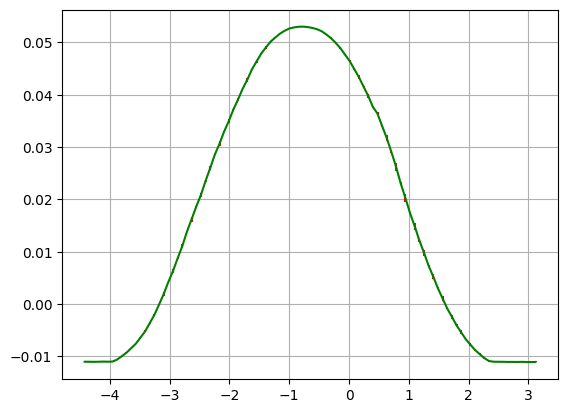

In [74]:

pc_mean = np.mean(pc,axis=1)
pc_std = np.std(pc,axis=1)

plt.errorbar(tx_poses,pc_mean,pc_std,c='g',ecolor='r')
plt.grid()
plt.show()

In [78]:
arg = np.argmax(pc_mean)
print(f'-{pc_mean[arg]} +- {pc_std[arg]}')
print(pc_mean[arg] - pc_std[arg])
print(pc_mean[arg] + pc_std[arg])


-0.05302187204360962 +- 3.452143981730218e-05
0.05298735060379232
0.053056393483426924


CA.Client.Exception...............................................
    Context: "10.30.14.19:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Wed Sep 03 2025 15:04:35.719163959
..................................................................
CA.Client.Exception...............................................
    Context: "10.30.14.19:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Wed Sep 03 2025 16:01:47.233590869
..................................................................
CA.Client.Exception...............................................
    Context: "10.30.14.19:46631"
    Source File: ../cac.cpp line 1237
    Current Time: Wed Sep 03 2025 16:02:40.231333900
..................................................................


In [73]:
tx_poses[np.argmax(pc_mean)]

-0.7677535

In [77]:
CAX.mirror.tx_pos = tx_poses[np.argmax(pc_mean)]

Anotações

O limite inferior de tx do espelho é -4.500601

O limite superior de tx do espelho é 3.1973135

# offset

measures of photocollector with the photon and gamma shutter closed

In [10]:
photcols = list()
for _ in range(10):
    photcols.append(CAX.mirror.photocurrent_signal)
    time.sleep(1)

file.save_dataset(dsetname='photocollector',dsetdata=photcols)

In [11]:
photcols

[0.01110637653619051,
 0.011088716797530651,
 0.011089409701526165,
 0.011086785234510899,
 0.01112318690866232,
 0.011017010547220707,
 0.011223704554140568,
 0.010917247273027897,
 0.01118092704564333,
 0.01105720829218626]

In [ ]:
np.average(photcols), np.std(photcols)

(0.01108905728906393, 7.985230178592118e-05)

CA.Client.Exception...............................................
    Context: "10.30.14.19:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Thu Sep 04 2025 14:20:46.387670853
..................................................................
CA.Client.Exception...............................................
    Context: "10.30.14.19:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Thu Sep 04 2025 14:40:47.110428814
..................................................................
CA.Client.Exception...............................................
    Context: "10.30.14.19:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Thu Sep 04 2025 16:16:06.838129073
..................................................................
